# 02 — Statistiques descriptives et qualité des données


In [1]:
from pathlib import Path

OUTPUT_DIR = Path("../outputs")

DESC_TABLES_DIR = OUTPUT_DIR / "descriptive_statistics" / "tables"
DESC_FIGURES_DIR = OUTPUT_DIR / "descriptive_statistics" / "figures"

INF_TABLES_DIR = OUTPUT_DIR / "inferential_statistics" / "tables"
INF_FIGURES_DIR = OUTPUT_DIR / "inferential_statistics" / "figures"

for folder in [
    DESC_TABLES_DIR,
    DESC_FIGURES_DIR,
    INF_TABLES_DIR,
    INF_FIGURES_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Outputs prêts :", OUTPUT_DIR.resolve())

Outputs prêts : C:\Users\Lenovo\Documents\data-analysis\outputs


In [2]:
# 1. CHARGEMENT DU DATASET NETTOYÉ

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pyarrow.parquet as pq

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

parquet_path = Path("../data/processed/01_smartphones_cleaned.parquet")

print("Dossier actuel :", Path.cwd())
print("Fichier existe :", parquet_path.exists())

if not parquet_path.exists():
    raise FileNotFoundError(f"Fichier introuvable : {parquet_path}")

# Lecture spéciale pour éviter l'erreur dbdate
table = pq.read_table(parquet_path, use_pandas_metadata=False)
df = table.to_pandas(ignore_metadata=True)

print("Chargement réussi.")
print(f"Dimensions du dataset : {df.shape}")

display(df.head(3))
df.info()

Dossier actuel : C:\Users\Lenovo\Documents\data-analysis\notebooks
Fichier existe : True
Chargement réussi.
Dimensions du dataset : (340, 14)


,product_sk,name,brand,model,price,old_price,currency,discount,rating,reviews,url,source_site,scraped_at,scraped_date
0,5b739bdbdb5c2920ef6d7656824ddb56,"Apple iPhone 15, 128 Go - Jaune (Reconditionné)",apple,iphone 15,430.57,NaN,EUR,NaN,NaN,NaN,,amazon_fr,2026-04-26 22:02:19.748601+00:00,2026-04-26
1,87754977e4bfcb8854d9d95483a339a9,Apple iPhone 15 128Go - Bleu (Reconditionné),apple,iphone 15,429.15,NaN,EUR,NaN,NaN,NaN,,amazon_fr,2026-04-26 22:03:09.359821+00:00,2026-04-26
2,4db3a5912f569e26e2a61c6ea4a2b980,Apple iPhone 15 128Go - Vert (Reconditionné),apple,iphone 15,434.11,NaN,EUR,NaN,NaN,NaN,,amazon_fr,2026-04-26 22:03:09.975676+00:00,2026-04-26


<class 'pandas.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   product_sk    340 non-null    str                
 1   name          340 non-null    str                
 2   brand         340 non-null    str                
 3   model         340 non-null    str                
 4   price         340 non-null    float64            
 5   old_price     162 non-null    float64            
 6   currency      340 non-null    str                
 7   discount      162 non-null    str                
 8   rating        67 non-null     float64            
 9   reviews       69 non-null     float64            
 10  url           340 non-null    str                
 11  source_site   340 non-null    str                
 12  scraped_at    340 non-null    datetime64[us, UTC]
 13  scraped_date  340 non-null    object             
dtypes: datetime64[us, UTC

In [3]:
# PRÉPARATION DES DOSSIERS OUTPUTS

from pathlib import Path

OUTPUT_DIR = Path("../outputs")

# Statistiques descriptives
DESC_TABLES_DIR = OUTPUT_DIR / "descriptive_statistics" / "tables"
DESC_FIGURES_DIR = OUTPUT_DIR / "descriptive_statistics" / "figures"

# Statistiques inférentielles
INF_TABLES_DIR = OUTPUT_DIR / "inferential_statistics" / "tables"
INF_FIGURES_DIR = OUTPUT_DIR / "inferential_statistics" / "figures"

# Création automatique des dossiers si nécessaire
for folder in [
    DESC_TABLES_DIR,
    DESC_FIGURES_DIR,
    INF_TABLES_DIR,
    INF_FIGURES_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dossiers outputs prêts.")
print("Chemin outputs :", OUTPUT_DIR.resolve())

Dossiers outputs prêts.
Chemin outputs : C:\Users\Lenovo\Documents\data-analysis\outputs


In [4]:

# 2. NETTOYAGE MINIMAL AVANT ANALYSE 


# Conversion des colonnes numériques
for col in ["price", "old_price", "discount", "rating", "reviews"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Standardisation du nom des plateformes
if "source_site" in df.columns:
    df["source_site"] = df["source_site"].astype(str).str.strip().str.lower()

    df["source_site"] = df["source_site"].replace({
        "amazon": "Amazon",
        "amazon fr": "Amazon",
        "amazon.fr": "Amazon",
        "jumia": "Jumia",
        "jumia ma": "Jumia",
        "jumia.ma": "Jumia",
        "electroplanet": "Electroplanet",
        "electro planet": "Electroplanet"
    })
else:
    print("Attention : la colonne source_site est absente.")

# Standardisation de la devise
if "currency" in df.columns:
    df["currency_clean"] = df["currency"].astype(str).str.strip().replace({
        "Dhs": "MAD",
        "DH": "MAD",
        "DHS": "MAD",
        "MAD": "MAD",
        "EUR": "EUR",
        "€": "EUR"
    })
else:
    df["currency_clean"] = "MAD"

# Conversion temporelle
if "scraped_at" in df.columns:
    df["scraped_at"] = pd.to_datetime(df["scraped_at"], errors="coerce")

if "scraped_date" in df.columns:
    df["scraped_date"] = pd.to_datetime(df["scraped_date"], errors="coerce").dt.date
elif "scraped_at" in df.columns:
    df["scraped_date"] = df["scraped_at"].dt.date
else:
    df["scraped_date"] = pd.NaT

# ------------------------------------------------------------
# conversion EURO en MAD
# ------------------------------------------------------------
EUR_TO_MAD = 11.0

df["price_mad"] = df["price"]

if "old_price" in df.columns:
    df["old_price_mad"] = df["old_price"]

mask_eur = df["currency_clean"] == "EUR"
df.loc[mask_eur, "price_mad"] = df.loc[mask_eur, "price"] * EUR_TO_MAD

if "old_price_mad" in df.columns:
    df.loc[mask_eur, "old_price_mad"] = df.loc[mask_eur, "old_price"] * EUR_TO_MAD

# Dataset final pour l'analyse descriptive : toutes les plateformes en MAD, y compris Amazon
if "price_mad" in df.columns:
    df_mad = df[df["price_mad"].notna() & (df["price_mad"] > 0)].copy()
else:
    raise ValueError("La colonne price est absente : impossible de faire les statistiques descriptives.")

print(f"Nombre de lignes exploitables après conversion en MAD : {len(df_mad)}")

if "source_site" in df_mad.columns:
    print("Plateformes présentes dans l'analyse :")
    display(df_mad["source_site"].value_counts().to_frame("nombre_lignes"))

print("Statistiques de base du prix converti en MAD :")
display(df_mad["price_mad"].describe().to_frame().T)


Nombre de lignes exploitables après conversion en MAD : 340
Plateformes présentes dans l'analyse :


,nombre_lignes
source_site,
jumia_ma,269
Electroplanet,53
amazon_fr,18


Statistiques de base du prix converti en MAD :


,count,mean,std,min,25%,50%,75%,max
price_mad,340.0,5232.540676,5091.637441,39.0,1644.0,2994.5,6641.75,20999.0


In [5]:
# PRÉPARATION DES DOSSIERS OUTPUTS

OUTPUT_DIR = Path("../outputs")

DESC_TABLES_DIR = OUTPUT_DIR / "descriptive_statistics" / "tables"
DESC_FIGURES_DIR = OUTPUT_DIR / "descriptive_statistics" / "figures"

for folder in [DESC_TABLES_DIR, DESC_FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dossiers outputs descriptifs prêts.")
print("Chemin :", OUTPUT_DIR.resolve())

Dossiers outputs descriptifs prêts.
Chemin : C:\Users\Lenovo\Documents\data-analysis\outputs


In [6]:

# 3. MOYENNE, MÉDIANE ET VOLATILITÉ DES PRIX


mean_price = df_mad["price_mad"].mean()
median_price = df_mad["price_mad"].median()
std_price = df_mad["price_mad"].std()
coefficient_variation = (std_price / mean_price) * 100 if mean_price != 0 else np.nan

print(f"Prix moyen   : {mean_price:.2f} MAD")
print(f"Prix médian  : {median_price:.2f} MAD")
print(f"Écart-type   : {std_price:.2f} MAD")
print(f"Coefficient de variation : {coefficient_variation:.2f}%")


Prix moyen   : 5232.54 MAD
Prix médian  : 2994.50 MAD
Écart-type   : 5091.64 MAD
Coefficient de variation : 97.31%


In [7]:
mean_median_price_by_platform = df.groupby("source_site")["price"].agg(
    count="count",
    mean_price="mean",
    median_price="median",
    min_price="min",
    max_price="max"
).reset_index()

mean_median_price_by_platform.to_csv(
    DESC_TABLES_DIR / "mean_median_price_by_platform.csv",
    index=False
)

display(mean_median_price_by_platform)
print("Table sauvegardée : mean_median_price_by_platform.csv")

,source_site,count,mean_price,median_price,min_price,max_price
0,Electroplanet,53,7775.433962,6639.000,39.00,20999.00
1,amazon_fr,18,399.807222,441.055,13.82,873.47
2,jumia_ma,269,4787.375465,2790.000,49.00,20990.00


Table sauvegardée : mean_median_price_by_platform.csv


In [8]:
global_price_summary = pd.DataFrame({
    "metric": [
        "mean_price_mad",
        "median_price_mad",
        "std_price_mad",
        "coefficient_variation_percent"
    ],
    "value": [
        mean_price,
        median_price,
        std_price,
        coefficient_variation
    ],
    "interpretation": [
        "Prix moyen des smartphones en MAD.",
        "Prix médian des smartphones en MAD.",
        "Volatilité globale des prix.",
        "Dispersion relative des prix par rapport à la moyenne."
    ]
})

global_price_summary.to_csv(
    DESC_TABLES_DIR / "global_price_summary.csv",
    index=False
)

display(global_price_summary)
print("Sauvegardé : global_price_summary.csv")

,metric,value,interpretation
0,mean_price_mad,5232.540676,Prix moyen des smartphones en MAD.
1,median_price_mad,2994.500000,Prix médian des smartphones en MAD.
2,std_price_mad,5091.637441,Volatilité globale des prix.
3,coefficient_variation_percent,97.307174,Dispersion relative des prix par rapport à la ...


Sauvegardé : global_price_summary.csv


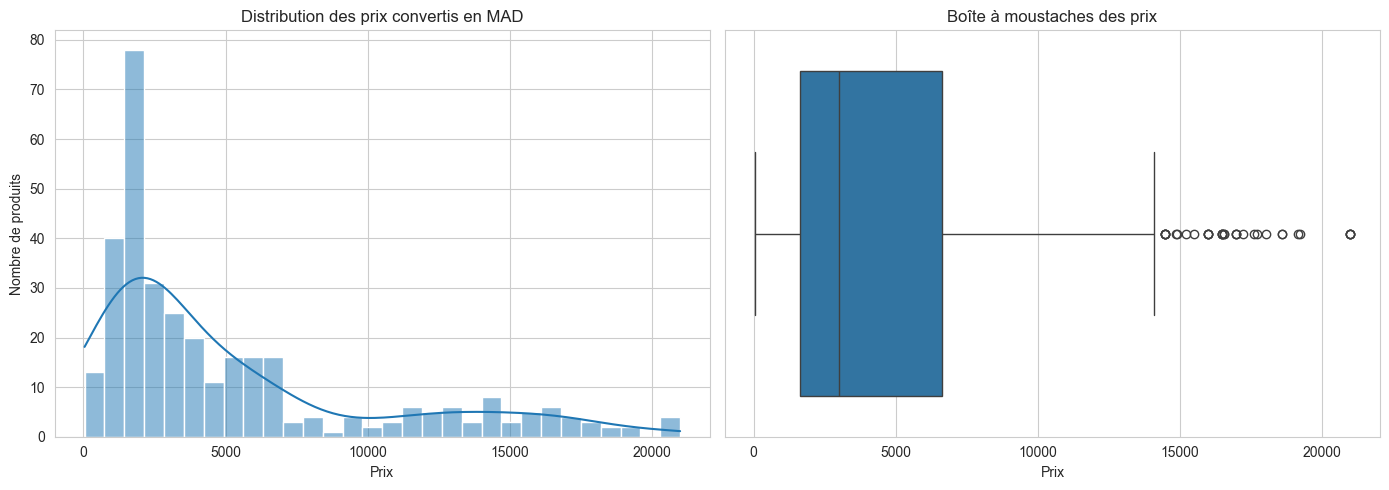

Figure sauvegardée : price_distribution_and_boxplot.png


In [9]:

# 4. DISTRIBUTION DES PRIX


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_mad["price_mad"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution des prix convertis en MAD")
axes[0].set_xlabel("Prix")
axes[0].set_ylabel("Nombre de produits")

sns.boxplot(x=df_mad["price_mad"], ax=axes[1])
axes[1].set_title("Boîte à moustaches des prix")
axes[1].set_xlabel("Prix")

plt.tight_layout()

plt.savefig(
    DESC_FIGURES_DIR / "price_distribution_and_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print("Figure sauvegardée : price_distribution_and_boxplot.png")


In [10]:

# 5. CALCUL DES RÉDUCTIONS DE PRIX


# On utilise old_price_mad et price_mad pour garder la même devise, y compris Amazon.
if "old_price_mad" in df_mad.columns and "price_mad" in df_mad.columns:
    df_discount = df_mad.dropna(subset=["old_price_mad", "price_mad"]).copy()

    df_discount["discount_amount"] = df_discount["old_price_mad"] - df_discount["price_mad"]
    df_discount["discount_pct"] = (df_discount["discount_amount"] / df_discount["old_price_mad"]) * 100

    df_discount = df_discount[
        (df_discount["old_price_mad"] > 0) &
        (df_discount["price_mad"] > 0) &
        (df_discount["discount_amount"] >= 0)
    ]

    print("Calcul des réductions terminé.")
    print(f"Nombre de produits avec réduction exploitable : {len(df_discount)}")
else:
    df_discount = pd.DataFrame()
    print("La colonne old_price est absente ou inexploitable : impossible de calculer les réductions.")


Calcul des réductions terminé.
Nombre de produits avec réduction exploitable : 162


In [11]:
# Sauvegarde des statistiques de réduction

if "df_discount" in globals() and not df_discount.empty:
    discount_summary = df_discount[["discount_amount", "discount_pct"]].describe().T.reset_index()
    discount_summary = discount_summary.rename(columns={"index": "metric"})

    discount_summary.to_csv(
        DESC_TABLES_DIR / "price_change_distribution.csv",
        index=False
    )

    display(discount_summary)
    print("Sauvegardé : price_change_distribution.csv")
else:
    print("Aucune donnée de réduction à sauvegarder.")

,metric,count,mean,std,min,25%,50%,75%,max
0,discount_amount,162.0,874.672840,1073.786004,39.000000,250.750000,440.000000,1100.000000,5899.00000
1,discount_pct,162.0,17.283746,12.188906,1.182176,9.658823,16.672708,22.140321,80.40201


Sauvegardé : price_change_distribution.csv


Nombre de produits avec réduction : 162


,metric,count,mean,std,min,25%,50%,75%,max
0,discount_amount,162.0,874.672840,1073.786004,39.000000,250.750000,440.000000,1100.000000,5899.00000
1,discount_pct,162.0,17.283746,12.188906,1.182176,9.658823,16.672708,22.140321,80.40201


Table sauvegardée : price_change_distribution.csv


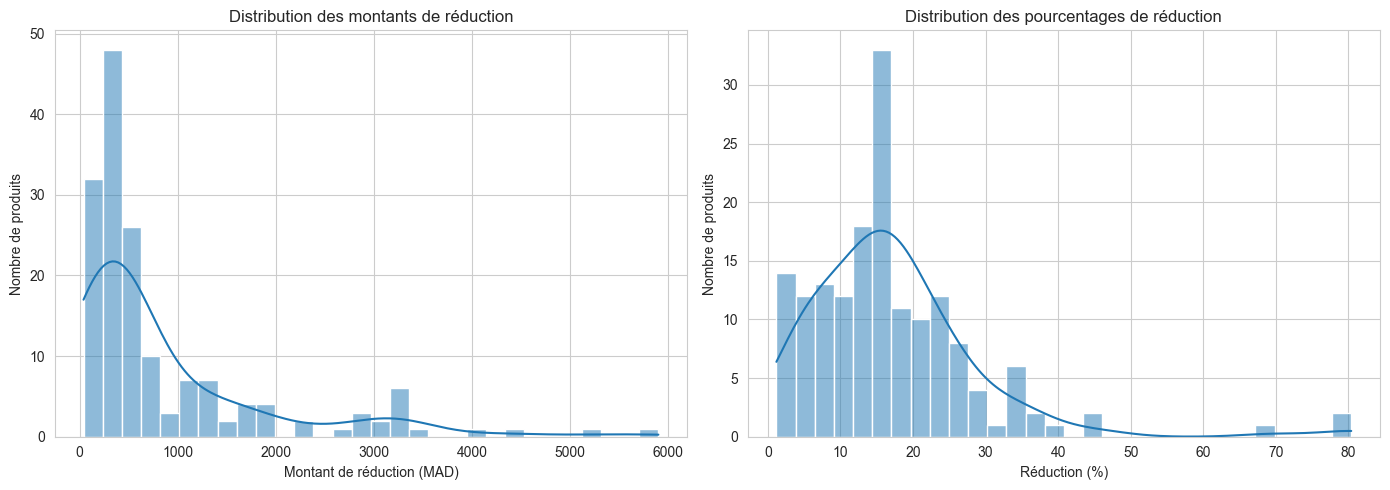

Figure sauvegardée : price_change_distribution.png


In [12]:
# 6. DISTRIBUTION DES RÉDUCTIONS DE PRIX


if "df_discount" in globals() and not df_discount.empty:

    print("Nombre de produits avec réduction :", len(df_discount))

    # Résumé statistique des réductions
    discount_summary = df_discount[["discount_amount", "discount_pct"]].describe().T.reset_index()
    discount_summary = discount_summary.rename(columns={"index": "metric"})

    display(discount_summary)

    # Sauvegarde du tableau dans outputs
    discount_summary.to_csv(
        DESC_TABLES_DIR / "price_change_distribution.csv",
        index=False
    )

    print("Table sauvegardée : price_change_distribution.csv")

    # Graphiques
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribution des montants de réduction
    sns.histplot(
        data=df_discount,
        x="discount_amount",
        bins=30,
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title("Distribution des montants de réduction")
    axes[0].set_xlabel("Montant de réduction (MAD)")
    axes[0].set_ylabel("Nombre de produits")

    # Distribution des pourcentages de réduction
    sns.histplot(
        data=df_discount,
        x="discount_pct",
        bins=30,
        kde=True,
        ax=axes[1]
    )

    axes[1].set_title("Distribution des pourcentages de réduction")
    axes[1].set_xlabel("Réduction (%)")
    axes[1].set_ylabel("Nombre de produits")

    plt.tight_layout()

    # Sauvegarde de la figure dans outputs
    plt.savefig(
        DESC_FIGURES_DIR / "price_change_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Figure sauvegardée : price_change_distribution.png")

else:
    print("Aucune donnée de réduction disponible.")
    print("Vérifie que la cellule précédente a bien créé df_discount.")

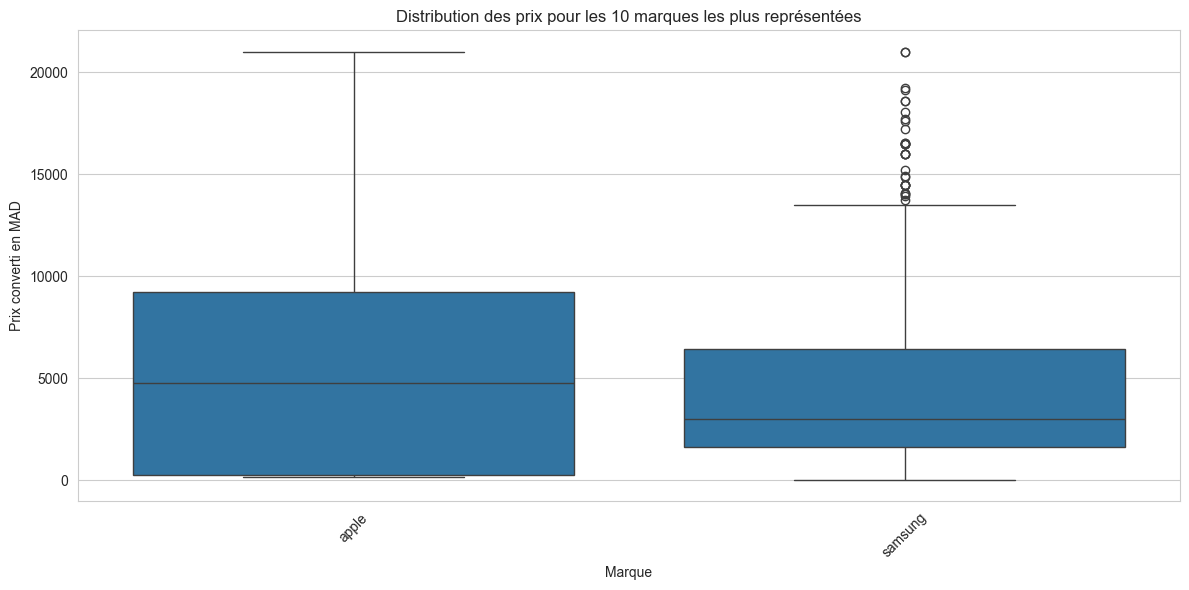

Figure sauvegardée : top_10_brands_price_boxplot.png


In [13]:
# 7. ANALYSE DES PRIX PAR MARQUE - TOP 10

if "brand" in df_mad.columns and "price_mad" in df_mad.columns:
    df_brand = df_mad.dropna(subset=["brand", "price_mad"]).copy()
    top_brands = df_brand["brand"].value_counts().head(10).index
    df_top_brands = df_brand[df_brand["brand"].isin(top_brands)]

    if not df_top_brands.empty:
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=df_top_brands, x="brand", y="price_mad")
        plt.title("Distribution des prix pour les 10 marques les plus représentées")
        plt.xlabel("Marque")
        plt.ylabel("Prix converti en MAD")
        plt.xticks(rotation=45)
        plt.tight_layout()

        plt.savefig(
            DESC_FIGURES_DIR / "top_10_brands_price_boxplot.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        print("Figure sauvegardée : top_10_brands_price_boxplot.png")

    else:
        print("Aucune donnée exploitable pour l'analyse par marque.")
else:
    print("Les colonnes 'brand' et/ou 'price_mad' sont absentes.")

In [14]:
df_stats = df.copy()

EUR_TO_MAD = 11

df_stats["price_mad"] = df_stats["price"]

df_stats.loc[df_stats["currency"] == "EUR", "price_mad"] = (
    df_stats.loc[df_stats["currency"] == "EUR", "price"] * EUR_TO_MAD
)

print(df_stats["source_site"].value_counts())

source_site
jumia_ma         269
Electroplanet     53
amazon_fr         18
Name: count, dtype: int64


,count,mean_price,median_price,std_price,min_price,max_price,coefficient_variation
source_site,,,,,,,
Electroplanet,53,7775.43,6639.0,7012.94,39.00,20999.00,0.9019
amazon_fr,18,4397.88,4851.6,2799.71,152.02,9608.17,0.6366
jumia_ma,269,4787.38,2790.0,4607.45,49.00,20990.00,0.9624


Table sauvegardée : mean_median_price_by_platform.csv
Table sauvegardée : price_volatility_by_platform.csv


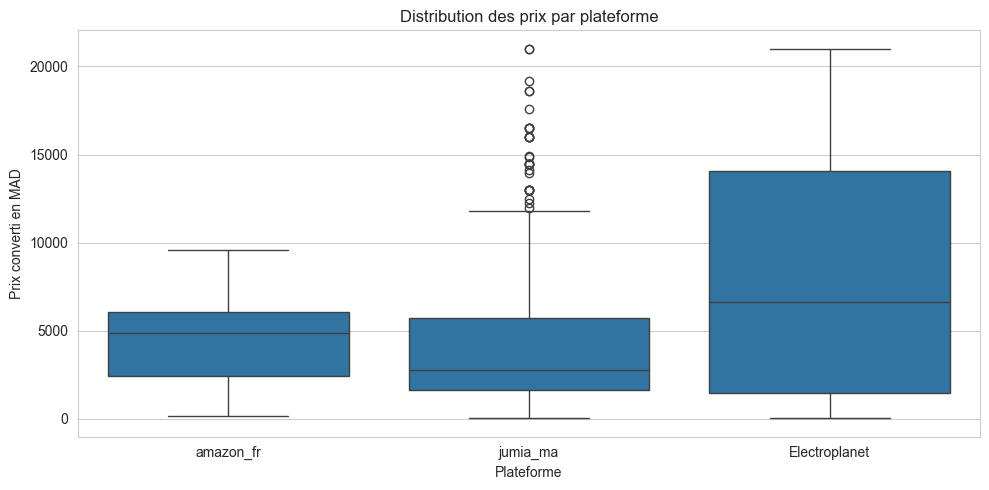

Figure sauvegardée : price_by_platform.png


In [15]:
# 8. STATISTIQUES DES PRIX PAR PLATEFORME

if "source_site" in df_mad.columns and "price_mad" in df_mad.columns:

    platform_stats = df_mad.groupby("source_site")["price_mad"].agg(
        count="count",
        mean_price="mean",
        median_price="median",
        std_price="std",
        min_price="min",
        max_price="max"
    ).round(2)

    platform_stats["coefficient_variation"] = (
        platform_stats["std_price"] / platform_stats["mean_price"]
    ).round(4)

    display(platform_stats)

    platform_stats.to_csv(
        DESC_TABLES_DIR / "mean_median_price_by_platform.csv"
    )

    platform_stats.to_csv(
        DESC_TABLES_DIR / "price_volatility_by_platform.csv"
    )

    print("Table sauvegardée : mean_median_price_by_platform.csv")
    print("Table sauvegardée : price_volatility_by_platform.csv")

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_mad, x="source_site", y="price_mad")
    plt.title("Distribution des prix par plateforme")
    plt.xlabel("Plateforme")
    plt.ylabel("Prix converti en MAD")
    plt.tight_layout()

    plt.savefig(
        DESC_FIGURES_DIR / "price_by_platform.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    print("Figure sauvegardée : price_by_platform.png")

else:
    print("Les colonnes 'source_site' et/ou 'price_mad' sont absentes.")